# **Nome e link do dataset**
Sistema de Cadastramento e Acompanhemento de Hipertensos e Diabéticos

Fonte: DATASUS [HIPERDIA](http://tabnet.datasus.gov.br/cgi/tabcgi.exe?hiperdia/cnv/hdam.def)

O dataset foi o acompanhamento em dez/2010 por município do Amazonas que dado um paciente com *Infarto agudo do miorcádio* demonstrou *hipertensão*.

In [22]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [23]:
df = pd.read_csv('/content/hiperdia_cnv_hdam.csv', sep=';')

In [24]:
print("Número de registros:", df.shape[0])
print("Número de colunas:", df.shape[1])

Número de registros: 31
Número de colunas: 4


In [25]:
df.head(10)

,Município,Sim,Não,Total
0,130006 AMATURA,-,27,27
1,130010 ANORI,-,1,1
2,130020 ATALAIA DO NORTE,-,4,4
3,130030 AUTAZES,-,36,36
4,130060 BENJAMIN CONSTANT,-,6,6
5,130063 BERURI,-,6,6
6,130070 BOCA DO ACRE,-,11,11
7,130080 BORBA,-,4,4
8,130090 CANUTAMA,-,2,2
9,130140 EIRUNEPE,-,1,1


In [26]:
df["Sim"] = df["Sim"].replace("-", 0)
df["Sim"] = pd.to_numeric(df["Sim"])
df["Sim"] = df["Sim"].astype(int)

In [27]:
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Município  31 non-null     object
 1   Sim        31 non-null     int64 
 2   Não        31 non-null     int64 
 3   Total      31 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.1+ KB


In [29]:
df_numeric = df.select_dtypes(include=[np.number])

In [30]:
df_numeric.mean()

,0
Sim,0.451613
Não,82.580645
Total,83.032258


In [31]:
df_numeric.median()

,0
Sim,0.0
Não,5.0
Total,5.0


In [32]:
df_numeric.mode().iloc[0]

,0
Sim,0
Não,1
Total,1


In [33]:
print("Mínimo:\n", df_numeric.min())
print("\nMáximo:\n", df_numeric.max())

Mínimo:
 Sim      0
Não      1
Total    1
dtype: int64

Máximo:
 Sim         7
Não      1280
Total    1287
dtype: int64


In [34]:
df_numeric.std()

,0
Sim,1.410407
Não,284.243297
Total,285.179415


In [35]:
df_numeric.var()

,0
Sim,1.989247
Não,80794.251613
Total,81327.298925


In [36]:
df_numeric.quantile([0.25, 0.5, 0.75])

,Sim,Não,Total
0.25,0.0,1.5,1.5
0.50,0.0,5.0,5.0
0.75,0.0,16.0,18.5


In [37]:
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

IQR

,0
Sim,0.0
Não,14.5
Total,17.0


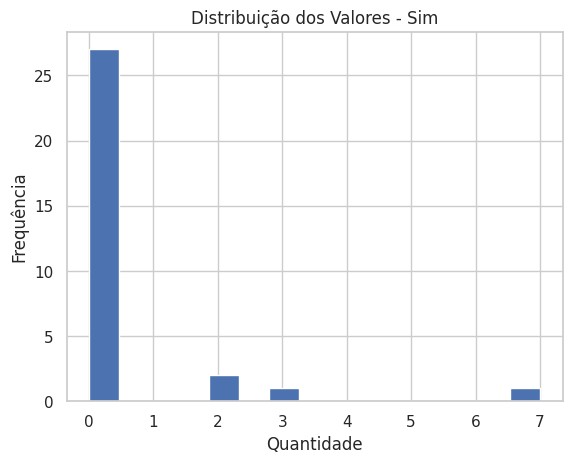

In [41]:
plt.figure()
plt.hist(df["Sim"], bins=15)
plt.title("Distribuição dos Valores - Sim")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()

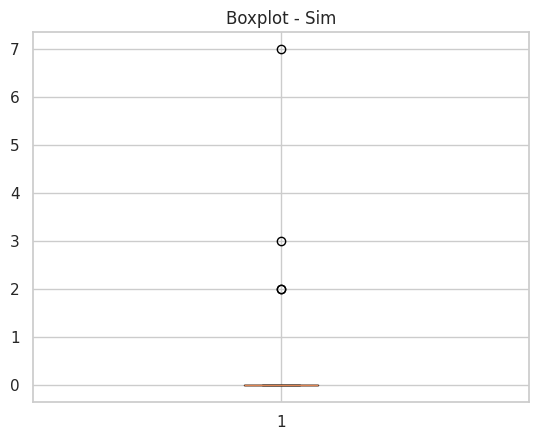

In [42]:
plt.figure()
plt.boxplot(df["Sim"])
plt.title("Boxplot - Sim")
plt.show()

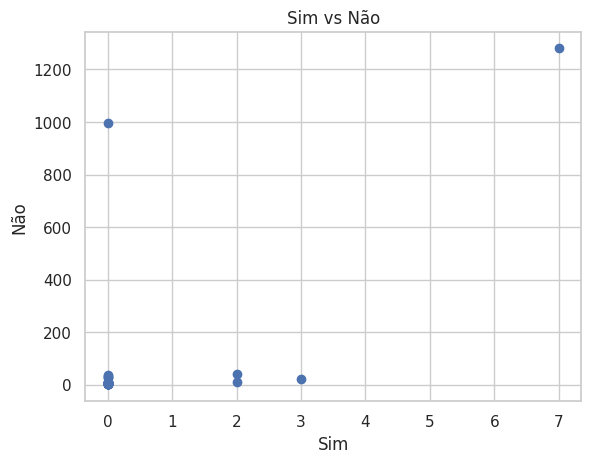

In [43]:
df["Não"] = (
    pd.to_numeric(df["Não"].replace("-", 0))
    .fillna(0)
    .astype(int)
)

plt.figure()
plt.scatter(df["Sim"], df["Não"])
plt.title("Sim vs Não")
plt.xlabel("Sim")
plt.ylabel("Não")
plt.show()

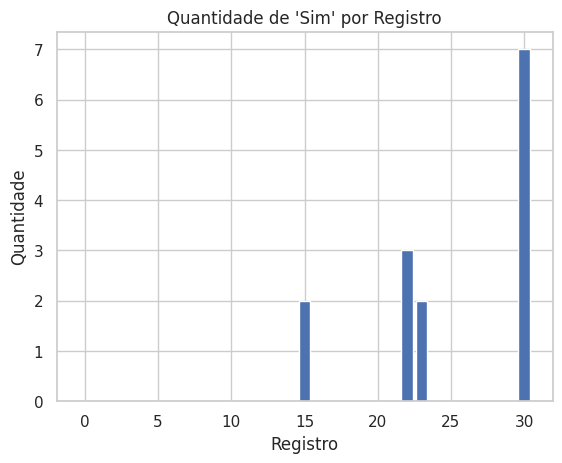

In [44]:
plt.figure()
plt.bar(range(len(df)), df["Sim"])
plt.title("Quantidade de 'Sim' por Registro")
plt.xlabel("Registro")
plt.ylabel("Quantidade")
plt.show()

In [45]:
df_numeric = df.select_dtypes(include=[np.number])

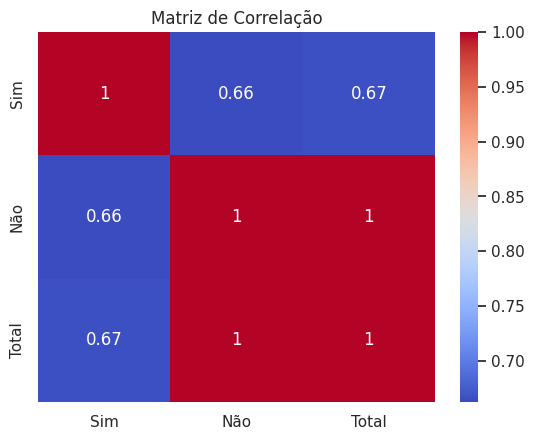

In [46]:
plt.figure()
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

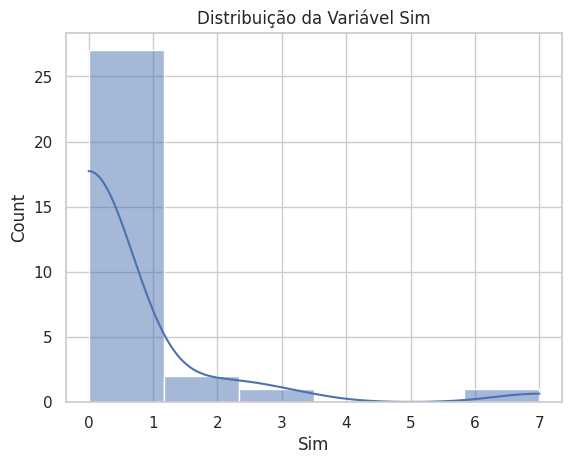

In [47]:
plt.figure()
sns.histplot(df["Sim"], kde=True)
plt.title("Distribuição da Variável Sim")
plt.show()

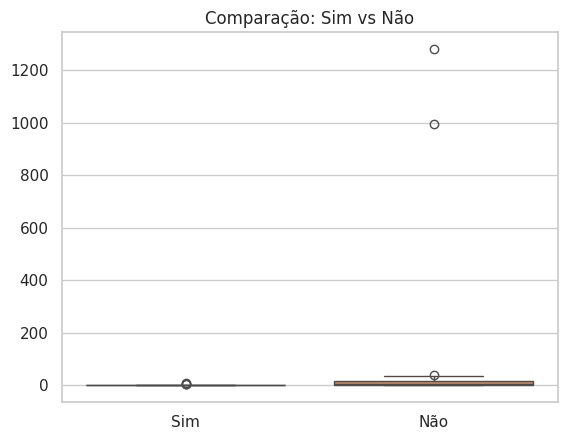

In [48]:
plt.figure()
sns.boxplot(data=df[["Sim", "Não"]])
plt.title("Comparação: Sim vs Não")
plt.show()

In [49]:
df

,Município,Sim,Não,Total
0,130006 AMATURA,0,27,27
1,130010 ANORI,0,1,1
2,130020 ATALAIA DO NORTE,0,4,4
3,130030 AUTAZES,0,36,36
4,130060 BENJAMIN CONSTANT,0,6,6
5,130063 BERURI,0,6,6
6,130070 BOCA DO ACRE,0,11,11
7,130080 BORBA,0,4,4
8,130090 CANUTAMA,0,2,2
9,130140 EIRUNEPE,0,1,1


# Comentando os resultados
Na análise dos dados foi possível perceber que as variáveis apresentam uma distribuição concentrada em valores mais baixos, com poucos registros apresentando números mais altos. Isso faz com que a distribuição não seja uniforme e indique uma assimetria nos dados. Pelo histograma, nota-se que a maior parte das ocorrências está agrupada, enquanto alguns valores se destacam.

No boxplot também foram identificados alguns valores extremos, o que pode indicar que determinados registros possuem comportamento diferente da maioria. Esses outliers podem representar situações específicas ou concentração maior do fenômeno analisado em alguns casos.

Ao observar a correlação entre as variáveis numéricas, percebe-se que algumas possuem relação entre si, principalmente quando representam categorias complementares. De modo geral, os dados mostram que o fenômeno não ocorre de maneira homogênea, apresentando variações entre os registros analisados.